In [8]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import nltk
from nltk.corpus import stopwords
import re

from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.decomposition import NMF

# 📂 PASSO 1: CARREGAMENTO DO CORPUS (BBC NEWS DATAFRAME)
------------------------------------------------------------------------------
Descrição: O algoritmo inicia lendo o arquivo estruturado. A função 'dropna()' 
garante que nenhuma linha sem texto quebre o fluxo de pré-processamento.


In [9]:
print("#" * 80)
print("## 📂 PASSO 1: CARREGANDO OS DADOS DA BBC NEWS")
print("#" * 80)

df = pd.read_csv("bbc-news-data.csv", sep='\t')
corpus = df["content"].dropna().tolist()

print(f"-> Sucesso: {len(corpus)} documentos de texto carregados prontos para análise.\n")

################################################################################
## 📂 PASSO 1: CARREGANDO OS DADOS DA BBC NEWS
################################################################################
-> Sucesso: 2225 documentos de texto carregados prontos para análise.



# 🧹 PASSO 2: PRÉ-PROCESSAMENTO E LIMPEZA DE TEXTO (NLP)

Descrição: Processo crítico de filtragem. Normaliza o texto para minúsculas,
elimina pontuações/números (ruídos matemáticos) e remove as 'Stop Words' 
em inglês para focar apenas nas palavras que carregam significado semântico.


In [10]:
print("#" * 80)
print("## 🧹 PASSO 2: EXECUTANDO PRÉ-PROCESSAMENTO E LIMPEZA (NLP)")
print("#" * 80)

nltk.download('stopwords', quiet=True)
palavras_irrelevantes = stopwords.words('english')

def limpar_texto(texto):
    texto = texto.lower()
    texto = re.sub(r'[^\w\s]', '', texto) 
    texto = re.sub(r'\d+', '', texto)      
    palavras = texto.split()
    palavras_limpas = [p for p in palavras if p not in palavras_irrelevantes]
    return " ".join(palavras_limpas)

corpus_limpo = [limpar_texto(doc) for doc in corpus]
print("-> Sucesso: Remoção de ruídos gramaticais e pontuações concluída.\n")

################################################################################
## 🧹 PASSO 2: EXECUTANDO PRÉ-PROCESSAMENTO E LIMPEZA (NLP)
################################################################################
-> Sucesso: Remoção de ruídos gramaticais e pontuações concluída.



# 🔢 PASSO 3: VETORIZAÇÃO E EXTRAÇÃO DE CARACTERÍSTICAS (TF-IDF)

Descrição: Converte os textos em uma Matriz numérica Documento-Termo (V). 
O cálculo do TF-IDF dá pesos maiores a palavras raras e contextualizadas, 
diminuindo a relevância de termos comuns que aparecem em quase todos os textos.

In [11]:
print("#" * 80)
print("## 🔢 PASSO 3: VETORIZAÇÃO DE MATRIZ VIA TF-IDF")
print("#" * 80)

vectorizer = TfidfVectorizer(max_df=0.95, min_df=2, max_features=2000, stop_words=palavras_irrelevantes)
V = vectorizer.fit_transform(corpus_limpo)

print(f"-> Dimensões da Matriz Original V [Documentos x Palavras]: {V.shape}\n")

################################################################################
## 🔢 PASSO 3: VETORIZAÇÃO DE MATRIZ VIA TF-IDF
################################################################################
-> Dimensões da Matriz Original V [Documentos x Palavras]: (2225, 2000)



# 🤖 PASSO 4: APLICANDO A FATORAÇÃO MATRICIAL NÃO-NEGATIVA (NMF)

Descrição: Decompõe a matriz V em duas submatrizes não-negativas:
W (Documentos x Tópicos) e H (Tópicos x Palavras). Definimos 5 componentes, 
mapeando-os diretamente para as 5 editorias conhecidas da BBC News.


In [12]:
print("#" * 80)
print("## 🤖 PASSO 4: DECOMPOSIÇÃO MATRICIAL COM NMF")
print("#" * 80)

n_topicos = 5
nmf_model = NMF(n_components=n_topicos, random_state=42, init='nndsvd')

W = nmf_model.fit_transform(V) 
H = nmf_model.components_      

nomes_topicos = {
    0: "Business (Negócios)",
    1: "Entertainment (Entretenimento)",
    2: "Politics (Política)",
    3: "Sport (Esportes)",
    4: "Tech (Tecnologia)"
}
print("-> Sucesso: Matrizes W e H geradas com restrição de não-negatividade.\n")


################################################################################
## 🤖 PASSO 4: DECOMPOSIÇÃO MATRICIAL COM NMF
################################################################################
-> Sucesso: Matrizes W e H geradas com restrição de não-negatividade.



# 📊 PASSO 5: EXTRAÇÃO DE INSIGHTS E PALAVRAS-CHAVE POR CATEGORIA
 Descrição: Varre a matriz H (Tópicos x Palavras) para extrair os termos com 
 maior peso matemático dentro de cada agrupamento latente gerado.
 

################################################################################
## 📊 PASSO 5: PALAVRAS-CHAVE MAIS IMPORTANTES POR CATEGORIA
################################################################################
📌 Business (Negócios)              -> Palavras: mr, labour, said, election, blair, party, would
📌 Entertainment (Entretenimento)   -> Palavras: game, england, win, said, cup, play, wales
📌 Politics (Política)              -> Palavras: bn, said, growth, us, year, sales, economy
📌 Sport (Esportes)                 -> Palavras: film, best, awards, award, actor, films, actress
📌 Tech (Tecnologia)                -> Palavras: people, mobile, music, technology, said, users, digital


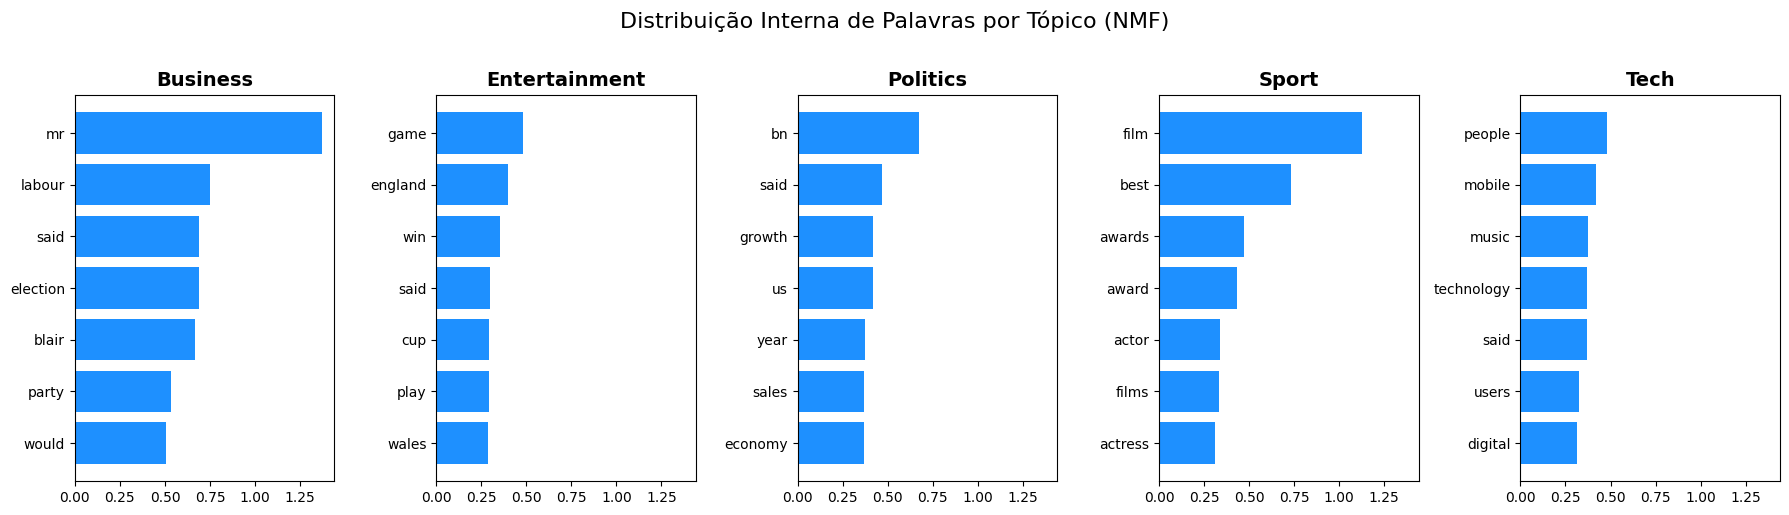

In [13]:

print("#" * 80)
print("## 📊 PASSO 5: PALAVRAS-CHAVE MAIS IMPORTANTES POR CATEGORIA")
print("#" * 80)

palavras_da_matriz = vectorizer.get_feature_names_out()
n_palavras_chave = 7  

for indice_topico, pesos_palavras in enumerate(H):
    top_indices = pesos_palavras.argsort()[:-n_palavras_chave-1:-1]
    top_palavras = [palavras_da_matriz[i] for i in top_indices]
    nome_real = nomes_topicos[indice_topico]
    print(f"📌 {nome_real:32} -> Palavras: {', '.join(top_palavras)}")

# --- PLOTAGEM DOS GRÁFICOS DE BARRAS ---
fig, axes = plt.subplots(1, n_topicos, figsize=(18, 5), sharex=True)
axes = axes.flatten()

for indice_topico, pesos_palavras in enumerate(H):
    top_indices = pesos_palavras.argsort()[:-n_palavras_chave-1:-1]
    top_palavras = [palavras_da_matriz[i] for i in top_indices]
    pesos = [pesos_palavras[i] for i in top_indices]
    
    ax = axes[indice_topico]
    ax.barh(top_palavras, pesos, color='dodgerblue')
    ax.set_title(nomes_topicos[indice_topico].split()[0], fontsize=14, fontweight='bold')
    ax.invert_yaxis()  

plt.suptitle("Distribuição Interna de Palavras por Tópico (NMF)", fontsize=16, y=1.02)
plt.tight_layout()
plt.show()

# 🍕 ANÁLISE EXTRA 1: DISTRIBUIÇÃO MACRO DE ASSUNTOS (MÉTRICA DE VOLUME) 
Descrição: Soma todos os pesos acumulados da matriz W para entender a fatia 
proporcional de cobertura que cada assunto tem no portal de notícias.



################################################################################
## 🍕 ANÁLISE EXTRA 1: BALANÇO GERAL DE VOLUMES DO PORTAL
################################################################################
📊 Business (Negócios)              representa  16.0% do acervo total.
📊 Entertainment (Entretenimento)   representa  24.2% do acervo total.
📊 Politics (Política)              representa  22.2% do acervo total.
📊 Sport (Esportes)                 representa  15.1% do acervo total.
📊 Tech (Tecnologia)                representa  22.5% do acervo total.


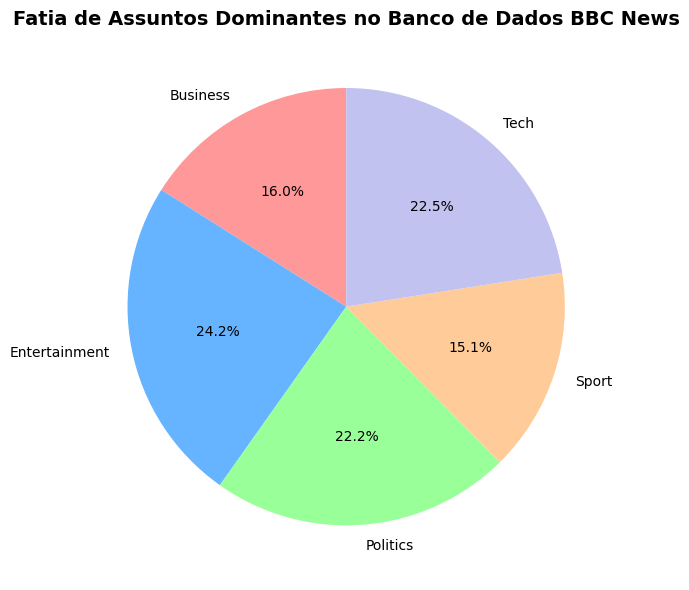

In [14]:
print("\n" + "#" * 80)
print("## 🍕 ANÁLISE EXTRA 1: BALANÇO GERAL DE VOLUMES DO PORTAL")
print("#" * 80)

proporcao_topicos = W.sum(axis=0)
porcentagens = (proporcao_topicos / proporcao_topicos.sum()) * 100

for idx, porcentagem in enumerate(porcentagens):
    print(f"📊 {nomes_topicos[idx]:32} representa {porcentagem:5.1f}% do acervo total.")

# --- PLOTAGEM DO GRÁFICO DE PIZZA ---
plt.figure(figsize=(8, 6))
plt.pie(porcentagens, labels=[v.split()[0] for v in nomes_topicos.values()], autopct='%1.1f%%', 
        colors=['#ff9999','#66b3ff','#99ff99','#ffcc99','#c2c2f0'], startangle=90)
plt.title("Fatia de Assuntos Dominantes no Banco de Dados BBC News", fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

# 🎯 ANÁLISE EXTRA 2: EXTRAÇÃO DE NOTÍCIAS COM CONTEXTO PURO
Descrição: Localiza o documento que obteve o maior score individual em cada
coluna da matriz W, trazendo à tona o texto padrão-ouro de cada assunto.


In [15]:
print("\n" + "#" * 80)
print("## 🎯 ANÁLISE EXTRA 2: NOTÍCIAS MODELO (CONTEXTO PURO)")
print("#" * 80)

for indice_topico, nome_real in nomes_topicos.items():
    id_documento_mais_puro = np.argmax(W[:, indice_topico])
    print(f"\n💡 Texto de referência máxima para [{nome_real}]:")
    print(f'"{corpus[id_documento_mais_puro][:220]}..."')


################################################################################
## 🎯 ANÁLISE EXTRA 2: NOTÍCIAS MODELO (CONTEXTO PURO)
################################################################################

💡 Texto de referência máxima para [Business (Negócios)]:
" Tony Blair has sought to reassure Labour backbenchers that nothing will stand in the way of the party's bid for a third term in power.  Mr Blair was speaking to MPs amid fresh rumours of a rift with Gordon Brown. A new ..."

💡 Texto de referência máxima para [Entertainment (Entretenimento)]:
" Former France centre Philippe Sella believes coach Bernard Laporte must recall Frederic Michalak to give his side any chance of beating Ireland.  Sella admitted he had been impressed by current fly-half Yann Delaigue in..."

💡 Texto de referência máxima para [Politics (Política)]:
" Barclays, the UK's third-biggest bank, has seen annual pre-tax profits climb to record levels boosted by a sharp rise in business at its investm

# 🔀 ANÁLISE EXTRA 3: RASTREAMENTO DE TEXTOS HÍBRIDOS (MISTOS)
Descrição: Scaneia a matriz W procurando linhas onde o segundo assunto mais
forte tem relevância expressiva. Identifica cruzamento de temas (ex: Tecnologia no Esporte).


In [16]:

print("\n" + "#" * 80)
print("## 🔀 ANÁLISE EXTRA 3: IDENTIFICAÇÃO DE MATÉRIAS COM TEXTO MISTO")
print("#" * 80)

for i, linha_pesos in enumerate(W[:500]): 
    indices_ordenados = linha_pesos.argsort()[::-1]
    maior_peso = linha_pesos[indices_ordenados[0]]
    segundo_maior_peso = linha_pesos[indices_ordenados[1]]
    
    if segundo_maior_peso > (maior_peso * 0.45) and maior_peso > 0.05:
        topico_1 = nomes_topicos[indices_ordenados[0]].split()[0]
        topico_2 = nomes_topicos[indices_ordenados[1]].split()[0]
        print(f"📰 Notícia Híbrida Encontrada (Índice {i})")
        print(f"   ├─ Assunto 1 Predominante: {topico_1} (Peso: {maior_peso:.3f})")
        print(f"   ├─ Assunto 2 Secundário:   {topico_2} (Peso: {segundo_maior_peso:.3f})")
        print(f'   └─ Trecho Real do Arquivo: "{corpus[i][:150]}..."\n')
        break


################################################################################
## 🔀 ANÁLISE EXTRA 3: IDENTIFICAÇÃO DE MATÉRIAS COM TEXTO MISTO
################################################################################
📰 Notícia Híbrida Encontrada (Índice 10)
   ├─ Assunto 1 Predominante: Politics (Peso: 0.068)
   ├─ Assunto 2 Secundário:   Tech (Peso: 0.041)
   └─ Trecho Real do Arquivo: " Ask Jeeves has become the third leading online search firm this week to thank a revival in internet advertising for improving fortunes.  The firm's r..."



# 🔮 BÔNUS: PREDIÇÃO E CLASSIFICAÇÃO DE DOCUMENTOS INÉDITOS
Descrição: Demonstração da aplicação em produção. Um texto inédito é limpo,
transformado no espaço vetorial TF-IDF e projetado na base NMF existente.

In [17]:
print("#" * 80)
print("## 🔮 BÔNUS: PREDIÇÃO DE TEXTOS COMPLETAMENTE NOVOS")
print("#" * 80)

texto_teste = ["The government prime minister voted against the economic and tax regulation today."]
texto_teste_limpo = [limpar_texto(texto_teste[0])]
v_teste = vectorizer.transform(texto_teste_limpo)
w_teste = nmf_model.transform(v_teste)

indice_vencedor = np.argmax(w_teste[0])
nome_vencedor = nomes_topicos[indice_vencedor]

print(f"Entrada: '{texto_teste[0]}'")
print(f"Pesos de afinidade calculados pelo NMF: {np.round(w_teste[0], 3)}")
print(f"--> Categoria sugerida automaticamente: {nome_vencedor}")
print("#" * 80)

################################################################################
## 🔮 BÔNUS: PREDIÇÃO DE TEXTOS COMPLETAMENTE NOVOS
################################################################################
Entrada: 'The government prime minister voted against the economic and tax regulation today.'
Pesos de afinidade calculados pelo NMF: [0.058 0.    0.015 0.    0.   ]
--> Categoria sugerida automaticamente: Business (Negócios)
################################################################################
